<a href="https://colab.research.google.com/github/vamshigitt/Covid_Hackathon/blob/main/Challenge_submission_group_42_order_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **COVID Vaccine Prediction — Model: LightGBM**


### **Author: Maneesh Kumar Panduga**

## **1. Imports**

In [ ]:
import warnings, re; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_curve)
SEED=42; TARGET='covid_vaccine'; ID='respondent_id'
from lightgbm import LGBMClassifier

In [ ]:
from google.colab import files
upload = files.upload()

Saving dataset_C_testing.csv to dataset_C_testing.csv
Saving dataset_C_training.csv to dataset_C_training.csv


In [ ]:
train=pd.read_csv('dataset_C_training.csv');
test=pd.read_csv('dataset_C_testing.csv')
y=train[TARGET].values; print('train',train.shape,'test',test.shape); train.head()

train (4756, 31) test (4749, 30)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


## **3. Preprocessing**

In [ ]:
# Group C (Adavi) preprocessing: one-hot + frequency encoding for employment_sector + median fill
CAT=['age_group','education','race','sex','income_poverty','marital_status','rent_or_own','employment_status','census_msa']
FREQ='employment_sector'
def prepare(df_tr,df_te):
    tr=df_tr.drop(columns=[ID]).copy(); te=df_te.drop(columns=[ID]).copy()
    beh=['behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask','behavioral_wash_hands',
         'behavioral_large_gatherings','behavioral_outside_home','behavioral_touch_face']
    for d in (tr,te):
        d['total_precautions']=d[beh].sum(axis=1)
        d['opinion_mean']=d[['opinion_covid_vacc_effective','opinion_covid_risk','opinion_covid_sick_from_vacc']].mean(axis=1)
    freq=tr[FREQ].value_counts(normalize=True)
    tr['emp_freq']=tr[FREQ].map(freq).fillna(0); te['emp_freq']=te[FREQ].map(freq).fillna(0)
    tr=tr.drop(columns=[FREQ]); te=te.drop(columns=[FREQ])
    tr=pd.get_dummies(tr,columns=CAT,dummy_na=True); te=pd.get_dummies(te,columns=CAT,dummy_na=True)
    tr,te=tr.align(te,join='left',axis=1,fill_value=0)
    num=tr.select_dtypes('number').columns; med=tr[num].median()
    tr[num]=tr[num].fillna(med); te[num]=te[num].fillna(med)
    tr=tr.drop(columns=[TARGET],errors='ignore'); te=te.drop(columns=[TARGET],errors='ignore')
    clean=lambda c: re.sub(r'[^0-9A-Za-z_]+','_',str(c)).strip('_')
    tr.columns=[clean(c) for c in tr.columns]; te.columns=[clean(c) for c in te.columns]
    return tr,te
X,X_test=prepare(train,test); print('design matrix',X.shape)

design matrix (4756, 59)


## **4. Model**

In [ ]:
model=LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=30,
        subsample=0.85, subsample_freq=1, colsample_bytree=0.85, reg_lambda=1.0, random_state=SEED, verbose=-1)

## **5. Cross-Validation**

In [ ]:
# leak-free out-of-fold probabilities via 5-fold CV
cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
oof=cross_val_predict(model,X,y,cv=cv,method='predict_proba',n_jobs=5)[:,1]
print('5-fold OOF ROC-AUC: %.4f'%roc_auc_score(y,oof))

5-fold OOF ROC-AUC: 0.8217


## **6. Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)**

ROC-AUC  : 0.8217
Accuracy : 0.7803
Precision: 0.6962
Recall   : 0.5811
F1 score : 0.6335

                precision    recall  f1-score   support

Not vaccinated      0.812     0.877     0.843      3202
    Vaccinated      0.696     0.581     0.633      1554

      accuracy                          0.780      4756
     macro avg      0.754     0.729     0.738      4756
  weighted avg      0.774     0.780     0.775      4756



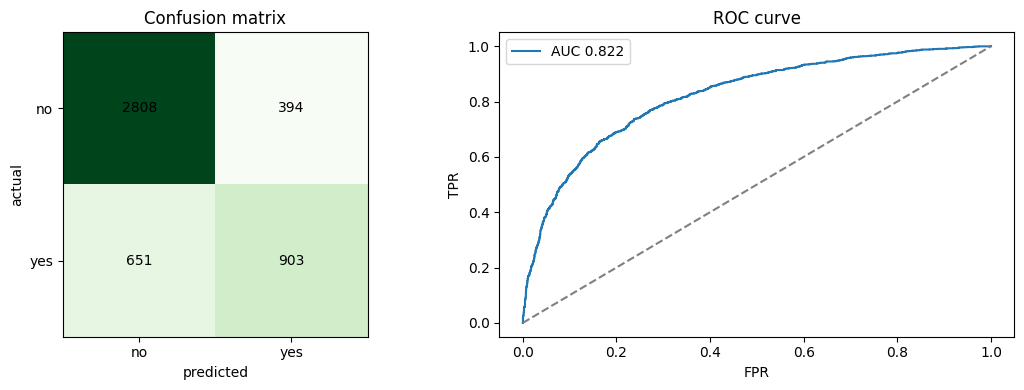

In [ ]:
# ---- full evaluation: ROC-AUC, Accuracy, Precision, Recall, F1 ----
pred=(oof>=0.5).astype(int)
print('ROC-AUC  : %.4f'%roc_auc_score(y,oof))
print('Accuracy : %.4f'%accuracy_score(y,pred))
print('Precision: %.4f'%precision_score(y,pred))
print('Recall   : %.4f'%recall_score(y,pred))
print('F1 score : %.4f'%f1_score(y,pred))
print('\n'+classification_report(y,pred,target_names=['Not vaccinated','Vaccinated'],digits=3))
cm=confusion_matrix(y,pred); fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].imshow(cm,cmap='Greens'); ax[0].set_title('Confusion matrix'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual')
ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1]); ax[0].set_xticklabels(['no','yes']); ax[0].set_yticklabels(['no','yes'])
for i in range(2):
    for j in range(2): ax[0].text(j,i,cm[i,j],ha='center',va='center')
fpr,tpr,_=roc_curve(y,oof); ax[1].plot(fpr,tpr,label='AUC %.3f'%roc_auc_score(y,oof)); ax[1].plot([0,1],[0,1],'--',c='grey')
ax[1].set_title('ROC curve'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend(); plt.tight_layout(); plt.show()

## **7. Feature Importance (XAI)**

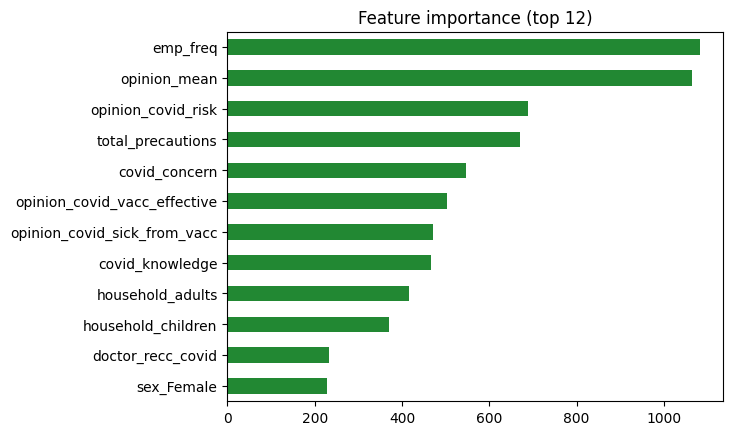

In [ ]:
model.fit(X,y)
pd.Series(model.feature_importances_,index=X.columns).sort_values().tail(12).plot(kind='barh',color='#228833')
plt.title('Feature importance (top 12)'); plt.show()

## **8. Submission**

In [ ]:
model.fit(X,y); proba=model.predict_proba(X_test)[:,1]
out=pd.DataFrame({ID:test[ID],TARGET:proba}); out.to_csv('submission_lightgbm.csv',index=False)